# Inter-protein interactions analysis in Aβ39 WT and G25D tetramers

## This notebook analyzes molecular dynamics trajectories of Aβ39 wild‑type (WT) and G25D mutant tetramers.
## It computes contact maps, backbone hydrogen bonds, oligomeric states, salt‑bridge formation (D23–K28) and domain‑specific contacts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from itertools import combinations, product
import os, sys

import MDAnalysis as mda
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis as HBA
from MDAnalysis.lib.distances import distance_array
from scipy.stats import ttest_ind, ks_2samp
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# ----------------------------------------------------------------------
# Plot settings
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

# Custom colors and labels
COLORS = {"WT": "magenta", "G25D": "cyan"}
LABELS = {"WT": "Wild-Type", "G25D": "G25D mutant"}

# Dark background for nicer rendering (optional, can be disabled)
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['legend.facecolor'] = 'black'
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams['grid.color'] = 'gray'

In [3]:
TPR_WT = "../XTCs_and_TPRs/NO_SOL/protein_only_WT.tpr"
XTC_WT = "../XTCs_and_TPRs/NO_SOL/protein_only_WT.xtc"
TPR_G25D = "../XTCs_and_TPRs/NO_SOL/protein_only_G25D.tpr"
XTC_G25D = "../XTCs_and_TPRs/NO_SOL/protein_only_G25D.xtc"

# Load universes
u_wt = mda.Universe(TPR_WT, XTC_WT)
u_mut = mda.Universe(TPR_G25D, XTC_G25D)
print(f"WT trajectory: {len(u_wt.trajectory)} frames, {len(u_wt.atoms)} atoms")
print(f"G25D trajectory: {len(u_mut.trajectory)} frames, {len(u_mut.atoms)} atoms")

WT trajectory: 16001 frames, 2328 atoms
G25D trajectory: 16001 frames, 2348 atoms


## 1. Chain definitions
### The tetramer consists of four chains (A, B, C, D), each with 39 residues.

In [4]:
RES_PER_MONOMER = 39
N_MONOMERS = 4
assert len(u_wt.residues) == N_MONOMERS * RES_PER_MONOMER, "Residue count mismatch"

# Residue indices (0‑based) for each chain
chains_wt = {
    'A': range(0, 39),
    'B': range(39, 78),
    'C': range(78, 117),
    'D': range(117, 156)
}
chains_mut = chains_wt.copy()   # same residue numbering

# Atom groups per chain
chain_atoms_wt = {ch: u_wt.residues[list(idx)].atoms for ch, idx in chains_wt.items()}
chain_atoms_mut = {ch: u_mut.residues[list(idx)].atoms for ch, idx in chains_mut.items()}

## 2. Inter‑protein contact maps (Cα–Cα)

In [5]:
CONTACT_THRESHOLD = 5.0   # Angstrom

def compute_contact_map(universe, start=0, stop=None, step=1):
    """Compute trajectory‑averaged Cα–Cα contact frequency matrix (156×156)."""
    n_res = len(universe.residues)
    contact_sum = np.zeros((n_res, n_res), dtype=np.float64)
    calphas = universe.select_atoms('name CA')
    calpha_resindices = calphas.resindices
    n_frames = 0

    for ts in universe.trajectory[start:stop:step]:
        pos = calphas.positions
        dist_mat = np.linalg.norm(pos[:, np.newaxis, :] - pos[np.newaxis, :, :], axis=2)
        contact_mask = dist_mat < CONTACT_THRESHOLD
        contact_sum += contact_mask.astype(np.float64)
        n_frames += 1

    return contact_sum / n_frames

print("Computing contact map for WT...")
contact_wt = compute_contact_map(u_wt)
print("Computing contact map for G25D...")
contact_mut = compute_contact_map(u_mut)

Computing contact map for WT...
Computing contact map for G25D...


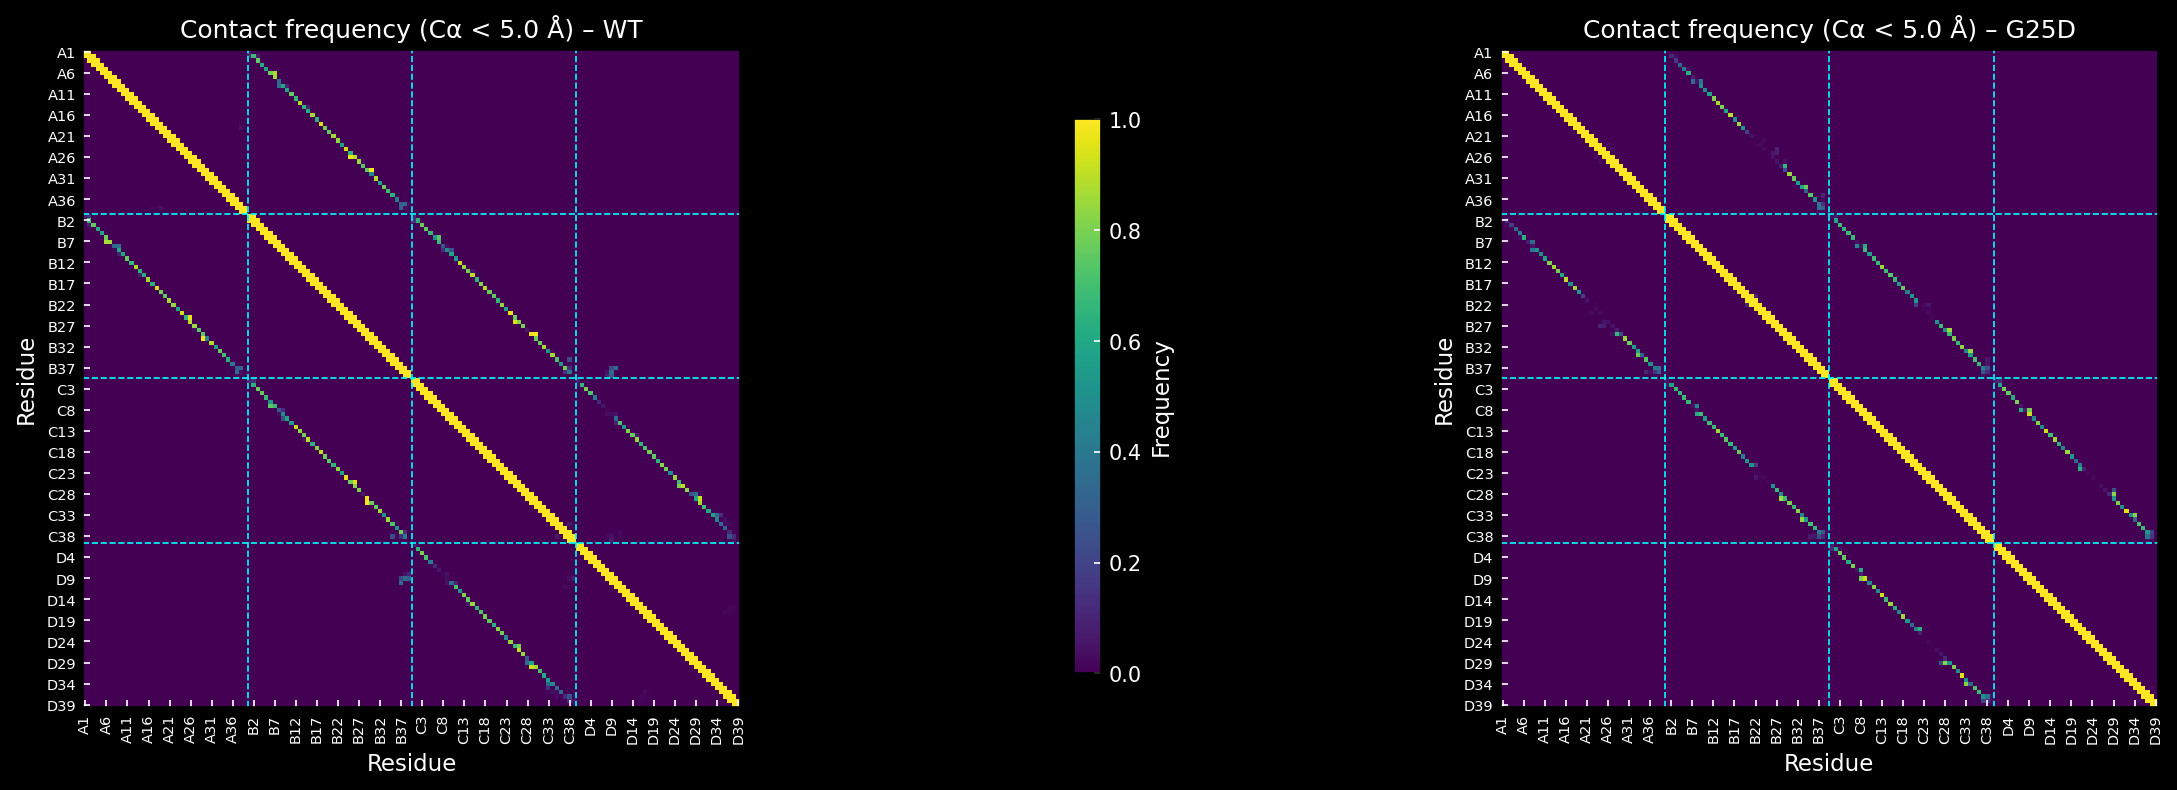

<Figure size 960x720 with 0 Axes>

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare labels for all 156 residues (chains A–D, residues 1–39 each)
chain_names = ['A', 'B', 'C', 'D']
tick_labels = []
for ch in chain_names:
    for i in range(1, 40):
        tick_labels.append(f'{ch}{i}')

# Positions to label: every 5th residue, include the last one (index 155)
tick_step = 5
tick_positions = list(range(0, 156, tick_step))
if 155 not in tick_positions:
    tick_positions.append(155)
tick_positions = sorted(tick_positions)
tick_labels_selected = [tick_labels[i] for i in tick_positions]

for ax, data, title in zip(axes, [contact_wt, contact_mut], ['WT', 'G25D']):
    im = ax.imshow(data, cmap='viridis', vmin=0, vmax=1, origin='upper')
    
    # Draw dashed lines between chains (after each block of 39 residues)
    for i in range(1, 4):
        ax.axhline(y=i * 39 - 0.5, color='cyan', lw=0.8, linestyle='--')
        ax.axvline(x=i * 39 - 0.5, color='cyan', lw=0.8, linestyle='--')
    
    # Axis formatting
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_selected, rotation=90, fontsize=7)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels_selected, fontsize=7)
    
    ax.set_xlabel('Residue')
    ax.set_ylabel('Residue')
    ax.set_title(f'Contact frequency (Cα < {CONTACT_THRESHOLD} Å) – {title}')

cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('Frequency')
fig.subplots_adjust(right=1.3, wspace=0.35, bottom=0.15)
plt.show()
plt.savefig('../../images/tetramers_contact_maps_WT_vs_G25D.png', dpi=300, bbox_inches='tight')

### The contacts between monomers in the region of 21-28 amino acid residues have noticeably weakened in the mutant protein and were in the range of values ​​close to 0

## 3. Inter‑protein backbone hydrogen bonds

In [7]:
HBA_D_A_CUTOFF = 3.0        # Å
HBA_D_H_A_ANGLE = 150.0     # degrees
STEP = 1                    # analyse every frame

def compute_inter_backbone_hbonds(universe, label):
    """Return time (ns) and counts of inter‑chain backbone H‑bonds."""
    u = universe
    n_frames = len(u.trajectory)
    time_ns = np.array([ts.time for ts in u.trajectory]) / 1000.0

    # assign each atom to its monomer (0..3)
    atom_protein_id = np.zeros(len(u.atoms), dtype=int)
    for idx, resid in enumerate(u.atoms.resids):
        atom_protein_id[idx] = (resid - 1) // RES_PER_MONOMER

    hb = HBA(
        universe=u,
        donors_sel='protein and name N',
        hydrogens_sel='protein and name HN',
        acceptors_sel='protein and name O',
        d_a_cutoff=HBA_D_A_CUTOFF,
        d_h_a_angle_cutoff=HBA_D_H_A_ANGLE,
        update_selections=True
    )
    hb.run(step=STEP)
    hbonds = hb.results.hbonds   # [frame, donor_idx, H_idx, acceptor_idx, dist, angle]

    if len(hbonds) == 0:
        print(f"[{label}] No hydrogen bonds found.")
        return None, None

    inter_hb_counts = np.zeros(n_frames, dtype=int)
    for row in hbonds:
        frame = int(row[0])
        donor = int(row[1])
        acceptor = int(row[3])
        if atom_protein_id[donor] != atom_protein_id[acceptor]:
            inter_hb_counts[frame] += 1

    analyzed_frames = np.arange(0, n_frames, STEP)
    time_analyzed = time_ns[analyzed_frames]
    counts_analyzed = inter_hb_counts[analyzed_frames]

    mean_val = np.mean(counts_analyzed)
    std_val = np.std(counts_analyzed)
    print(f"[{label}] Inter‑protein backbone H‑bonds: {mean_val:.2f} ± {std_val:.2f} "
          f"(min {counts_analyzed.min()}, max {counts_analyzed.max()})")
    return time_analyzed, counts_analyzed

time_wt, counts_wt = compute_inter_backbone_hbonds(u_wt, "WT")
time_mut, counts_mut = compute_inter_backbone_hbonds(u_mut, "G25D")

[WT] Inter‑protein backbone H‑bonds: 50.13 ± 5.25 (min 31, max 69)
[G25D] Inter‑protein backbone H‑bonds: 42.09 ± 4.59 (min 26, max 68)


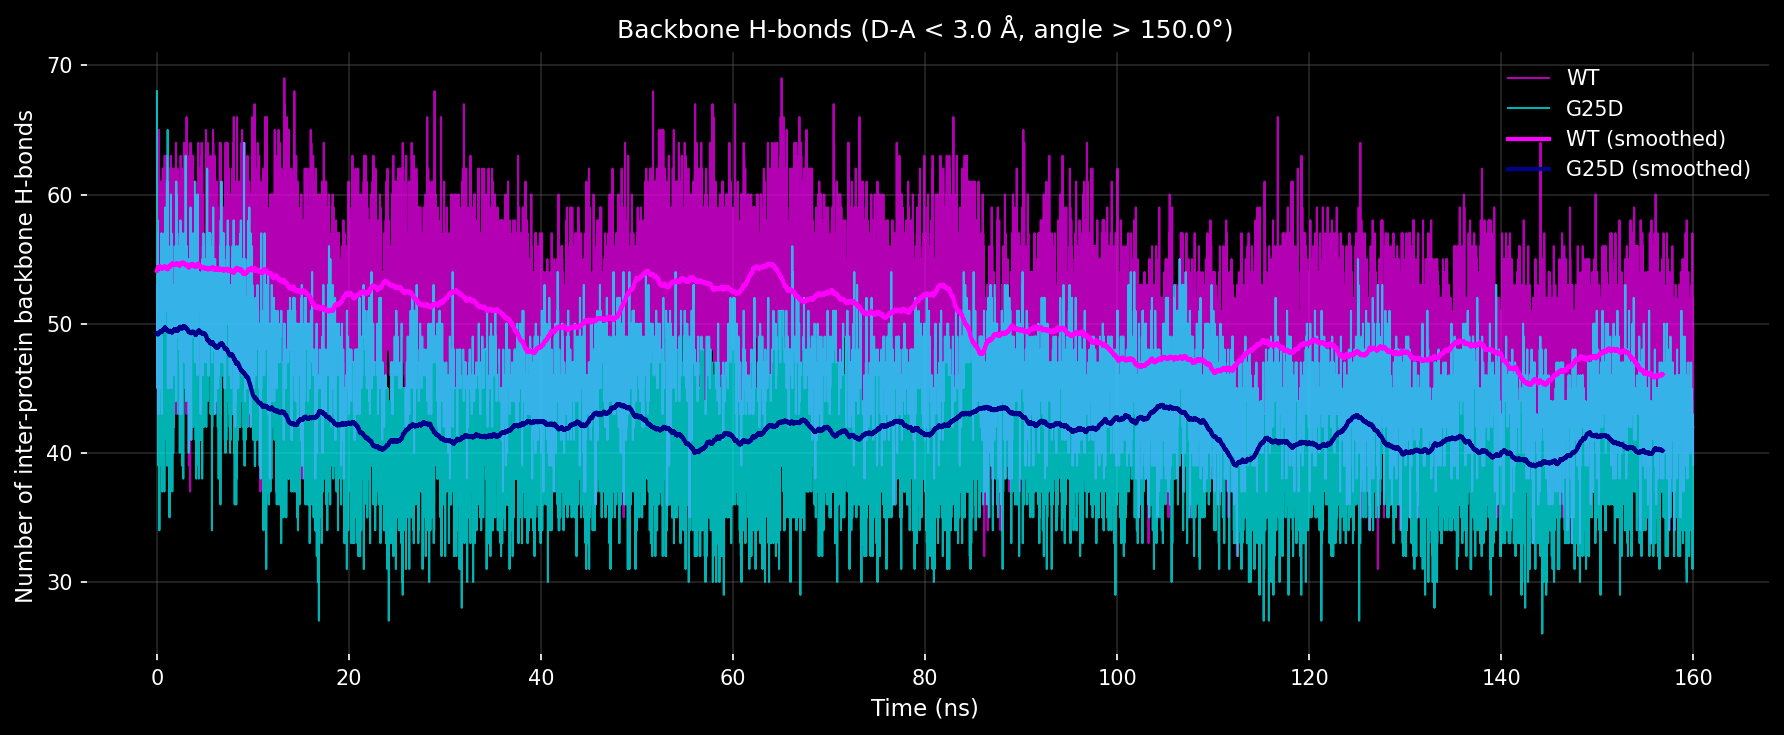

<Figure size 960x720 with 0 Axes>

In [8]:
# Plot time series
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time_wt, counts_wt, lw=1.0, color=COLORS["WT"], alpha=0.7, label='WT')
ax.plot(time_mut, counts_mut, lw=1.0, color=COLORS["G25D"], alpha=0.7, label='G25D')

# moving average for smoothing
window = max(1, len(counts_wt)//50)
if window > 1:
    smooth_wt = np.convolve(counts_wt, np.ones(window)/window, mode='valid')
    ax.plot(time_wt[:len(smooth_wt)], smooth_wt, lw=2, color='magenta', label='WT (smoothed)')
    smooth_mut = np.convolve(counts_mut, np.ones(window)/window, mode='valid')
    ax.plot(time_mut[:len(smooth_mut)], smooth_mut, lw=2, color='darkblue', label='G25D (smoothed)')

ax.set_xlabel('Time (ns)')
ax.set_ylabel('Number of inter‑protein backbone H‑bonds')
ax.set_title(f'Backbone H‑bonds (D‑A < {HBA_D_A_CUTOFF} Å, angle > {HBA_D_H_A_ANGLE}°)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../../images/tetramers_backbone_hbonds_timeseries.png', dpi=300, bbox_inches='tight')

In [9]:
# Statistical test (Welch's t‑test on block averages)
BLOCK_SIZE = 500
def block_average(counts, block_size):
    n_blocks = len(counts) // block_size
    if n_blocks < 2:
        raise ValueError("Block size too large.")
    blocks = counts[:n_blocks * block_size].reshape(n_blocks, block_size)
    return blocks.mean(axis=1)

blocks_wt = block_average(counts_wt, BLOCK_SIZE)
blocks_mut = block_average(counts_mut, BLOCK_SIZE)
t_stat, p_val = ttest_ind(blocks_wt, blocks_mut, equal_var=False)
print(f"\nWelch's t‑test (block size {BLOCK_SIZE}): t = {t_stat:.3f}, p = {p_val:.2e}")
if p_val < 0.05:
    print("Difference in means is statistically significant (p < 0.05).")


Welch's t‑test (block size 500): t = 13.415, p = 1.27e-19
Difference in means is statistically significant (p < 0.05).


### The average number of hydrogen bonds differs statistically significantly; in the tetramer of the mutant protein G25D, the average number of hydrogen bonds between monomers is noticeably less than in Wild Type. (42 vs 50)

## 4. Oligomeric state analysis (inter‑chain contacts)

In [10]:
CHAIN_CONTACT_THRESHOLD = 5.0   # Å (Cα‑Cα)

def get_interchain_contact_matrix(universe, chain_atoms_dict, threshold):
    """Return 4×4 boolean contact matrix for current frame (based on Cα distances)."""
    labels = sorted(chain_atoms_dict.keys())
    n = len(labels)
    contact = np.zeros((n, n), dtype=bool)
    for i, j in combinations(range(n), 2):
        ca_i = chain_atoms_dict[labels[i]].select_atoms('name CA')
        ca_j = chain_atoms_dict[labels[j]].select_atoms('name CA')
        dist = np.linalg.norm(ca_i.positions[:, np.newaxis] - ca_j.positions, axis=2)
        if dist.min() < threshold:
            contact[i, j] = contact[j, i] = True
    return contact, labels

def classify_oligomeric_state(contact_matrix):
    """Classify state based on connected components of the 4×4 contact matrix."""
    n = contact_matrix.shape[0]
    visited = [False]*n
    components = []
    for v in range(n):
        if not visited[v]:
            queue = [v]
            visited[v] = True
            comp_size = 0
            while queue:
                node = queue.pop(0)
                comp_size += 1
                for nb in range(n):
                    if contact_matrix[node, nb] and not visited[nb]:
                        visited[nb] = True
                        queue.append(nb)
            components.append(comp_size)
    components.sort(reverse=True)
    if components == [4]:
        return "tetramer"
    elif components == [3,1]:
        return "trimer+monomer"
    elif components == [2,2]:
        return "two dimers"
    elif components == [2,1,1]:
        return "dimer+2 monomers"
    elif components == [1,1,1,1]:
        return "4 monomers"
    else:
        return f"unknown ({components})"

def compute_oligomer_timeseries(universe, chain_atoms_dict, threshold, start=0, stop=None, step=1):
    states = []
    for ts in universe.trajectory[start:stop:step]:
        contact_mat, _ = get_interchain_contact_matrix(universe, chain_atoms_dict, threshold)
        states.append(classify_oligomeric_state(contact_mat))
    return states

print("Analyzing oligomeric states for WT...")
states_wt = compute_oligomer_timeseries(u_wt, chain_atoms_wt, CHAIN_CONTACT_THRESHOLD)
print("Analyzing oligomeric states for G25D...")
states_mut = compute_oligomer_timeseries(u_mut, chain_atoms_mut, CHAIN_CONTACT_THRESHOLD)

counts_wt = Counter(states_wt)
counts_mut = Counter(states_mut)

print("\nState distribution (WT):")
for state, cnt in counts_wt.most_common():
    print(f"  {state}: {cnt} frames ({100*cnt/len(states_wt):.1f}%)")
print("\nState distribution (G25D):")
for state, cnt in counts_mut.most_common():
    print(f"  {state}: {cnt} frames ({100*cnt/len(states_mut):.1f}%)")

Analyzing oligomeric states for WT...
Analyzing oligomeric states for G25D...

State distribution (WT):
  tetramer: 16001 frames (100.0%)

State distribution (G25D):
  tetramer: 12862 frames (80.4%)
  two dimers: 1714 frames (10.7%)
  trimer+monomer: 1360 frames (8.5%)
  dimer+2 monomers: 65 frames (0.4%)


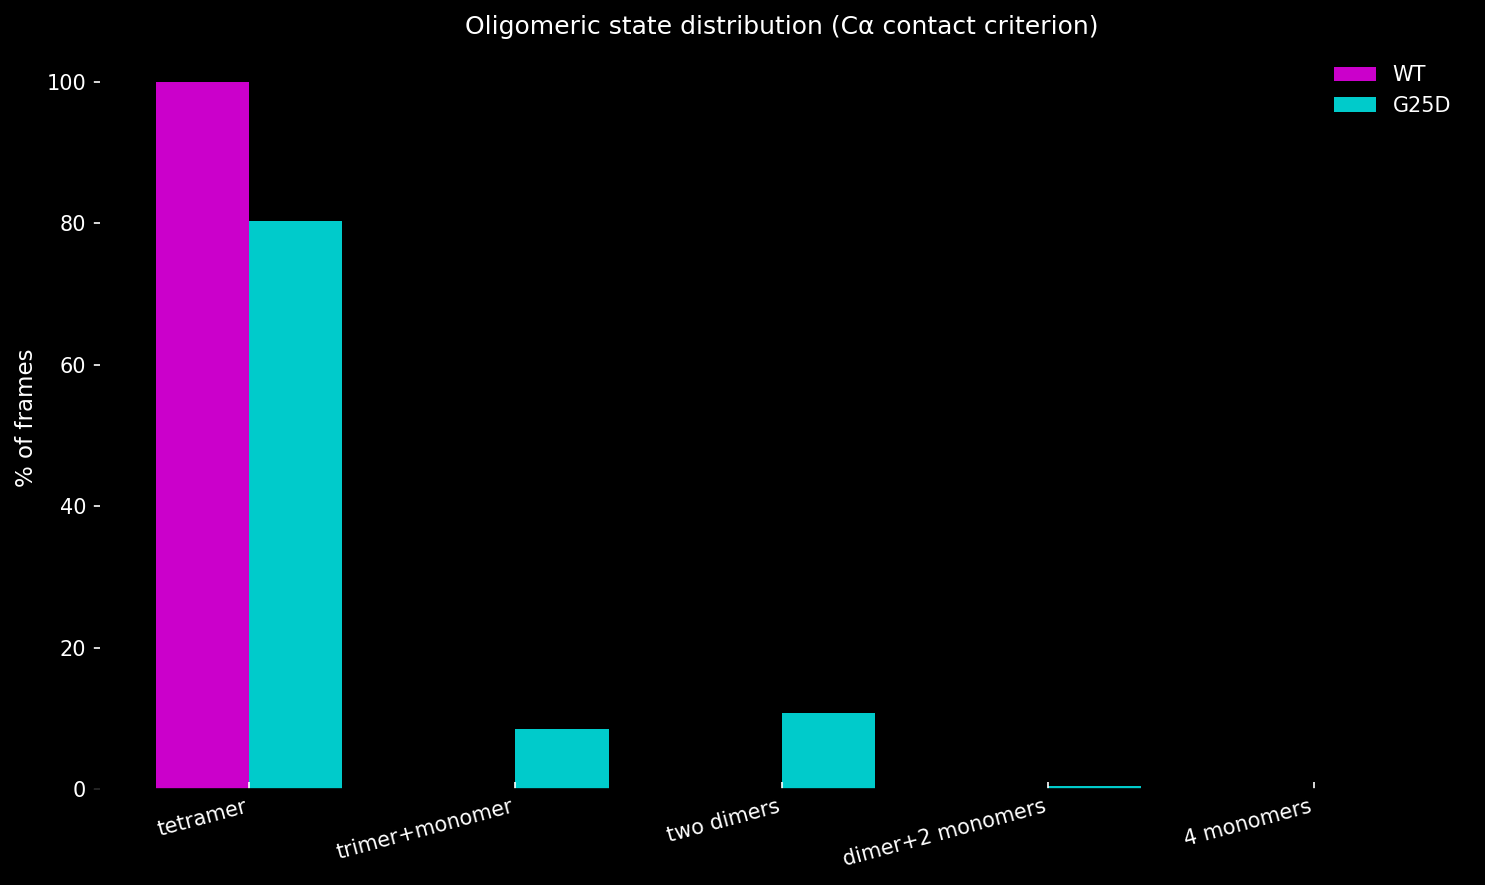

<Figure size 960x720 with 0 Axes>

In [11]:
# Bar plot comparison
states_order = ["tetramer", "trimer+monomer", "two dimers", "dimer+2 monomers", "4 monomers"]
wt_perc = [100 * counts_wt.get(s,0) / len(states_wt) for s in states_order]
mut_perc = [100 * counts_mut.get(s,0) / len(states_mut) for s in states_order]

x = np.arange(len(states_order))
width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, wt_perc, width, label='WT', color=COLORS["WT"], alpha=0.8)
ax.bar(x + width/2, mut_perc, width, label='G25D', color=COLORS["G25D"], alpha=0.8)
ax.set_ylabel('% of frames')
ax.set_title('Oligomeric state distribution (Cα contact criterion)')
ax.set_xticks(x)
ax.set_xticklabels(states_order, rotation=15, ha='right')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()
plt.savefig('../../images/chain_contact_oligomeric_states_distribution.png', dpi=300, bbox_inches='tight')

In [12]:
# Optionally, recompute using centers‑of‑mass (COM) for comparison
COM_DISTANCE_THRESHOLD = 16.0

def get_chain_centers_of_mass(universe, chain_atoms_dict):
    return {label: atoms.center_of_mass() for label, atoms in chain_atoms_dict.items()}

def get_interchain_com_contact_matrix(com_dict, threshold):
    labels = sorted(com_dict.keys())
    n = len(labels)
    contact = np.zeros((n, n), dtype=bool)
    for i, j in combinations(range(n), 2):
        dist = np.linalg.norm(com_dict[labels[i]] - com_dict[labels[j]])
        if dist < threshold:
            contact[i, j] = contact[j, i] = True
    return contact, labels

def compute_oligomer_timeseries_com(universe, chain_atoms_dict, threshold, start=0, stop=None, step=1):
    states = []
    for ts in universe.trajectory[start:stop:step]:
        coms = get_chain_centers_of_mass(universe, chain_atoms_dict)
        contact_mat, _ = get_interchain_com_contact_matrix(coms, threshold)
        states.append(classify_oligomeric_state(contact_mat))
    return states

print("\nCOM‑based analysis for WT...")
states_wt_com = compute_oligomer_timeseries_com(u_wt, chain_atoms_wt, COM_DISTANCE_THRESHOLD)
print("COM‑based analysis for G25D...")
states_mut_com = compute_oligomer_timeseries_com(u_mut, chain_atoms_mut, COM_DISTANCE_THRESHOLD)
counts_wt_com = Counter(states_wt_com)
counts_mut_com = Counter(states_mut_com)
print("\nCOM state distribution (WT):")
for state, cnt in counts_wt_com.most_common():
    print(f"  {state}: {cnt} frames ({100*cnt/len(states_wt_com):.1f}%)")
print("\nCOM state distribution (G25D):")
for state, cnt in counts_mut_com.most_common():
    print(f"  {state}: {cnt} frames ({100*cnt/len(states_mut_com):.1f}%)")


COM‑based analysis for WT...
COM‑based analysis for G25D...

COM state distribution (WT):
  tetramer: 16001 frames (100.0%)

COM state distribution (G25D):
  tetramer: 12862 frames (80.4%)
  two dimers: 1717 frames (10.7%)
  trimer+monomer: 1422 frames (8.9%)


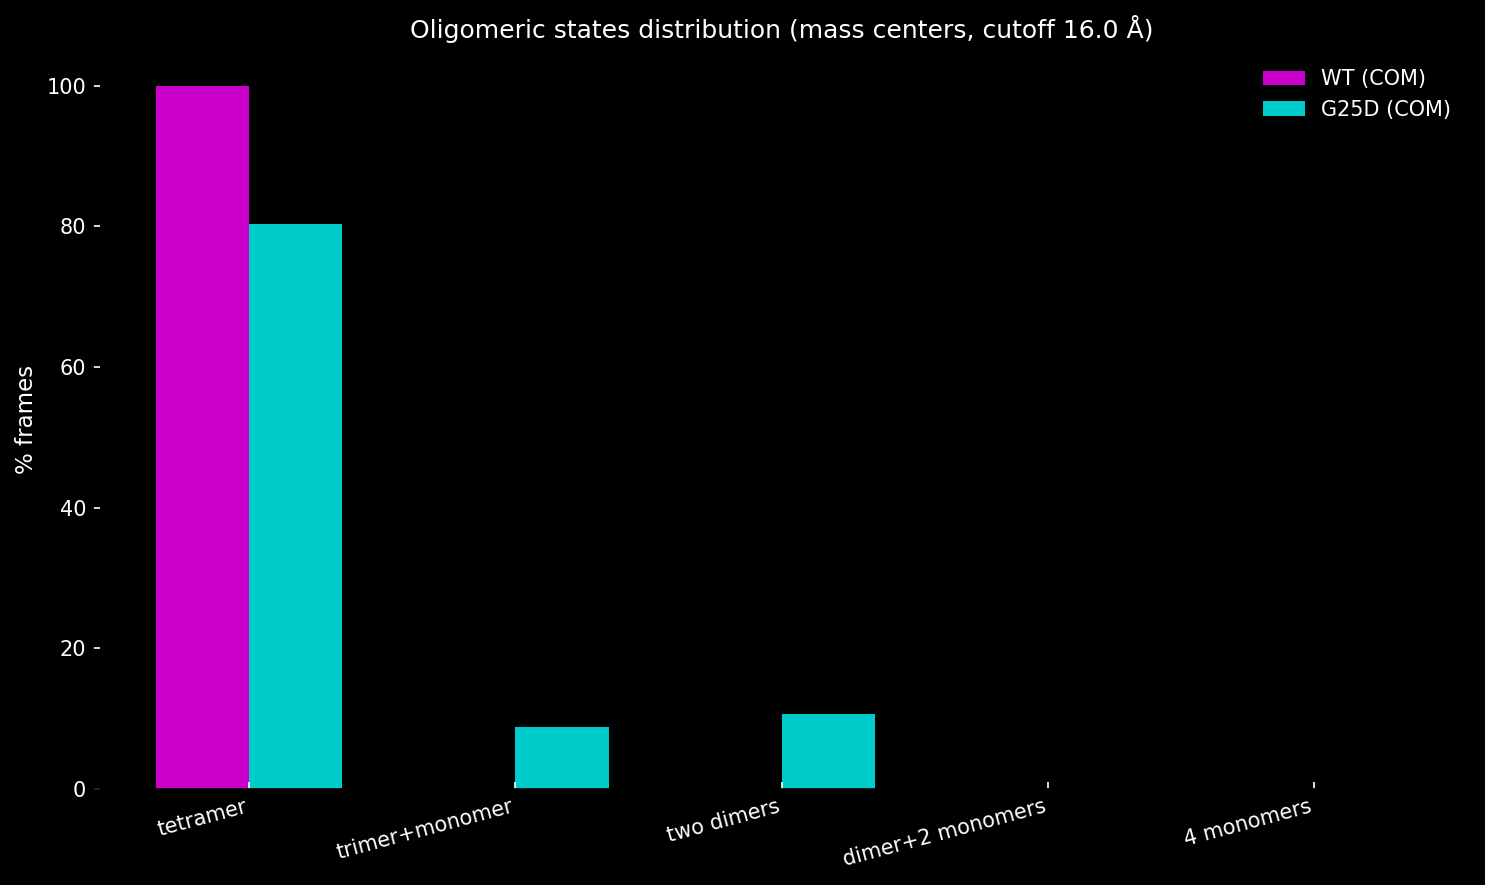

<Figure size 960x720 with 0 Axes>

In [13]:
states_order = ["tetramer", "trimer+monomer", "two dimers", "dimer+2 monomers", "4 monomers"]
wt_perc_com = [100 * counts_wt_com.get(s, 0) / len(states_wt_com) for s in states_order]
mut_perc_com = [100 * counts_mut_com.get(s, 0) / len(states_mut_com) for s in states_order]

x = np.arange(len(states_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, wt_perc_com, width, label='WT (COM)', color='magenta', alpha=0.8)
ax.bar(x + width/2, mut_perc_com, width, label='G25D (COM)', color='cyan', alpha=0.8)
ax.set_ylabel('% frames')
ax.set_title(f'Oligomeric states distribution (mass centers, cutoff {COM_DISTANCE_THRESHOLD} Å)')
ax.set_xticks(x)
ax.set_xticklabels(states_order, rotation=15, ha='right')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()
plt.savefig('../../images/mass_centers_oligomeric_states_distribution.png', dpi=300, bbox_inches='tight')

### Introducing the mutation significantly impacted the stability of the tetrameric structure, leading to its disintegration into individual components. The mutant G25D protein was disaggregated for approximately 20% of the simulation time, while the wild-type protein spent the entire simulation as a tetramer.

## 5. Salt‑bridge D23–K28 and E22-K28 analysis

In [14]:
SALT_BRIDGE_CUTOFF = 4.0   # Å (distance between O atoms of Asp23 and NZ of Lys28)

def get_interchain_salt_bridge_distances_by_index(universe, chain_atoms_dict, cutoff, start=0, stop=None, step=1):
    """
    Compute minimum distance between D23 (OD1/OD2) and K28 (NZ) for each inter‑chain pair.
    Returns dictionary of distance arrays and a flat array of all distances.
    """
    chain_labels = sorted(chain_atoms_dict.keys())
    n_frames = len(universe.trajectory[start:stop:step])
    pair_distances = {}
    all_dists = []

    ASP_INDEX = 22   # 0‑based index of residue 23
    LYS_INDEX = 27   # 0‑based index of residue 28

    for lab_i, lab_j in combinations(chain_labels, 2):
        chain_i = chain_atoms_dict[lab_i]
        chain_j = chain_atoms_dict[lab_j]

        residues_i = list(chain_i.residues)
        residues_j = list(chain_j.residues)

        if len(residues_i) <= max(ASP_INDEX, LYS_INDEX) or len(residues_j) <= max(ASP_INDEX, LYS_INDEX):
            raise ValueError(f"Chain {lab_i} or {lab_j} too short.")

        asp_i = residues_i[ASP_INDEX].atoms.select_atoms('name OD1 OD2')
        lys_i = residues_i[LYS_INDEX].atoms.select_atoms('name NZ')
        asp_j = residues_j[ASP_INDEX].atoms.select_atoms('name OD1 OD2')
        lys_j = residues_j[LYS_INDEX].atoms.select_atoms('name NZ')

        dist_ij = np.zeros(n_frames)
        dist_ji = np.zeros(n_frames)

        for frame_idx, ts in enumerate(universe.trajectory[start:stop:step]):
            box = ts.dimensions
            d1 = distance_array(asp_i.positions, lys_j.positions, box=box).min()
            d2 = distance_array(asp_j.positions, lys_i.positions, box=box).min()
            dist_ij[frame_idx] = d1
            dist_ji[frame_idx] = d2
            all_dists.append(d1)
            all_dists.append(d2)

        pair_distances[(lab_i, lab_j)] = (dist_ij, dist_ji)

    return pair_distances, np.array(all_dists)

print("Computing D23–K28 distances for WT...")
_, all_dists_wt = get_interchain_salt_bridge_distances_by_index(u_wt, chain_atoms_wt, SALT_BRIDGE_CUTOFF)
print("Computing D23–K28 distances for G25D...")
_, all_dists_mut = get_interchain_salt_bridge_distances_by_index(u_mut, chain_atoms_mut, SALT_BRIDGE_CUTOFF)

Computing D23–K28 distances for WT...
Computing D23–K28 distances for G25D...


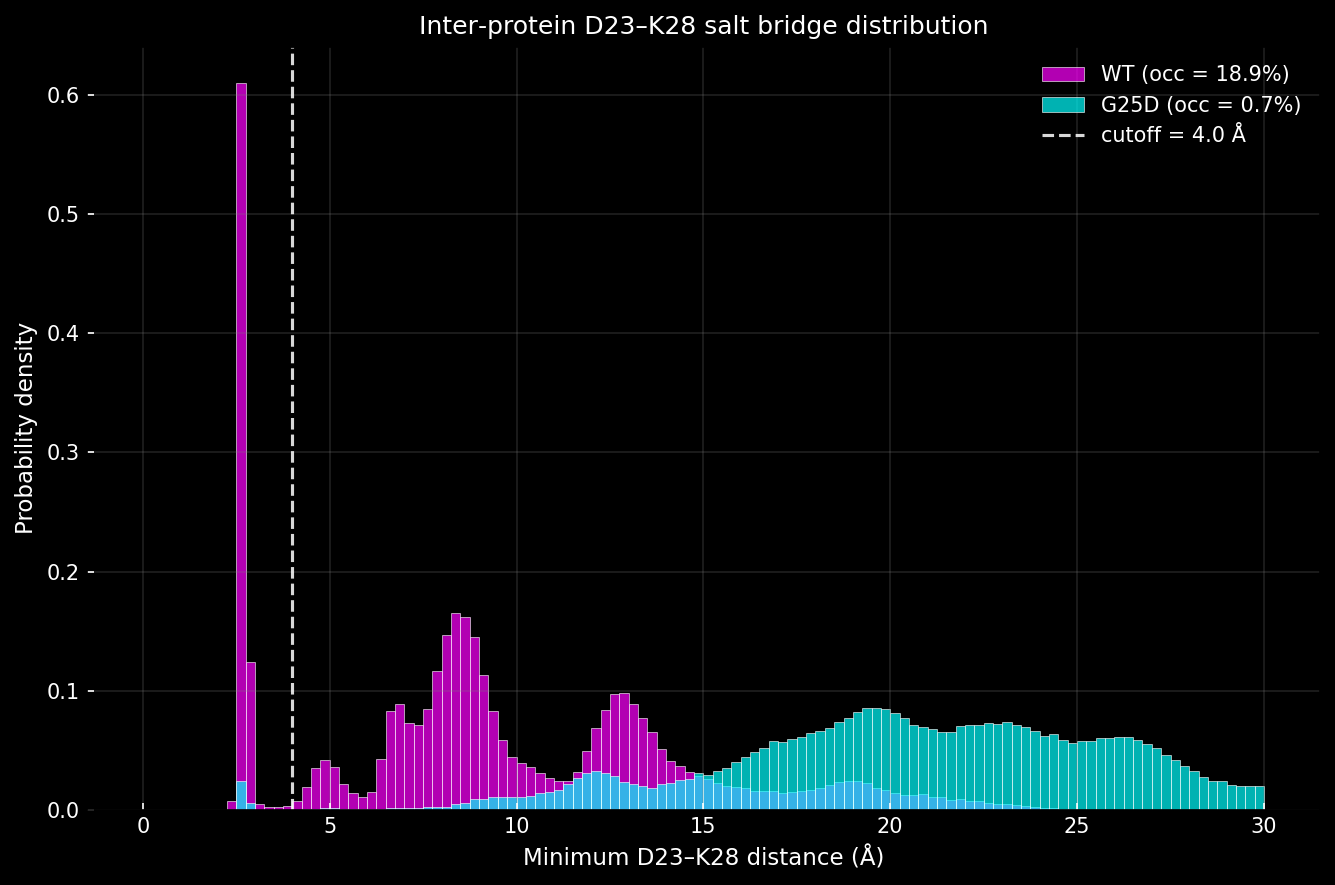

<Figure size 960x720 with 0 Axes>

In [15]:
# Plot histograms
fig, ax = plt.subplots(figsize=(9,6))
bins = np.linspace(0, 30, 121)
ax.hist(all_dists_wt, bins=bins, density=True, alpha=0.7,
        color=COLORS["WT"], label=f'WT (occ = {100*(all_dists_wt <= SALT_BRIDGE_CUTOFF).mean():.1f}%)',
        edgecolor='white', linewidth=0.4)
ax.hist(all_dists_mut, bins=bins, density=True, alpha=0.7,
        color=COLORS["G25D"], label=f'G25D (occ = {100*(all_dists_mut <= SALT_BRIDGE_CUTOFF).mean():.1f}%)',
        edgecolor='white', linewidth=0.4)
ax.axvline(SALT_BRIDGE_CUTOFF, ls='--', color='white', alpha=0.85, lw=1.5, label=f'cutoff = {SALT_BRIDGE_CUTOFF} Å')
ax.set_xlabel('Minimum D23–K28 distance (Å)')
ax.set_ylabel('Probability density')
ax.set_title('Inter‑protein D23–K28 salt bridge distribution')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
plt.savefig('../../images/salt_bridge_distance_distribution.png', dpi=300, bbox_inches='tight')

In [16]:
# Statistical tests
ks_stat, ks_p = ks_2samp(all_dists_wt, all_dists_mut)
print(f"\nKolmogorov‑Smirnov test: KS = {ks_stat:.4f}, p = {ks_p:.2e}")
if ks_p < 0.05:
    print("Distance distributions differ significantly.")

wt_success = np.sum(all_dists_wt <= SALT_BRIDGE_CUTOFF)
mut_success = np.sum(all_dists_mut <= SALT_BRIDGE_CUTOFF)
z_stat, z_p = proportions_ztest([wt_success, mut_success], [len(all_dists_wt), len(all_dists_mut)])
print(f"\nProportion test (occupancy): Z = {z_stat:.2f}, p = {z_p:.2e}")
if z_p < 0.05:
    print("Salt‑bridge occupancies differ significantly.")


Kolmogorov‑Smirnov test: KS = 0.7370, p = 0.00e+00
Distance distributions differ significantly.

Proportion test (occupancy): Z = 189.50, p = 0.00e+00
Salt‑bridge occupancies differ significantly.


### The introduction of the G25D mutation into the protein resulted in a statistically significant difference in the lifetime of the D23-K28 salt bridge, which is an important structure in stabilizing the hydrophobic core of the fibril. Occupancy was 18.9% for WT versus 0.7% for G25D.

## 6. Domain‑specific contacts

In [17]:
DOMAIN_CONTACT_CUTOFF = 6.0   # Å (Cα–Cα)

# Domain definitions (0‑based indices within each chain)
CHC_RESIDUES = list(range(16, 20))       # residues 17–21
TURN_RESIDUES = list(range(22, 27))      # residues 23–28
CTERM_RESIDUES = list(range(29, 38))     # residues 30–39 (C‑terminal)

def compute_domain_contacts(universe, chain_atoms_dict, cutoff, start=0, stop=None, step=1):
    """
    Compute average number of Cα contacts between domains for each pair of chains.
    Returns average contacts per pair per frame, and per‑frame series.
    """
    chain_labels = sorted(chain_atoms_dict.keys())
    n_pairs = len(chain_labels) * (len(chain_labels)-1) // 2
    frames = universe.trajectory[start:stop:step]
    n_frames = len(frames)

    contact_sums = {key: 0 for key in ['CHC–CHC', 'CHC–Cterm', 'Cterm–Cterm', 'Turn–Turn', 'Turn–CHC']}
    frame_contacts = {key: np.zeros(n_frames) for key in contact_sums}

    # Pre‑extract Cα atoms for each domain and chain
    chain_domains = {}
    for label in chain_labels:
        chain = chain_atoms_dict[label]
        residues = list(chain.residues)
        ca_chc = sum([residues[i].atoms.select_atoms('name CA') for i in CHC_RESIDUES])
        ca_turn = sum([residues[i].atoms.select_atoms('name CA') for i in TURN_RESIDUES])
        ca_cterm = sum([residues[i].atoms.select_atoms('name CA') for i in CTERM_RESIDUES])
        if not (len(ca_chc) and len(ca_turn) and len(ca_cterm)):
            raise ValueError(f"Chain {label}: missing Cα atoms in a domain")
        chain_domains[label] = {'chc': ca_chc, 'turn': ca_turn, 'cterm': ca_cterm}

    for frame_idx, ts in enumerate(frames):
        box = ts.dimensions
        for lab_i, lab_j in combinations(chain_labels, 2):
            di = chain_domains[lab_i]
            dj = chain_domains[lab_j]

            # CHC–CHC
            d = distance_array(di['chc'].positions, dj['chc'].positions, box=box)
            contact_sums['CHC–CHC'] += np.sum(d < cutoff)
            frame_contacts['CHC–CHC'][frame_idx] += np.sum(d < cutoff)

            # CHC–Cterm (direction i→j)
            d = distance_array(di['chc'].positions, dj['cterm'].positions, box=box)
            contact_sums['CHC–Cterm'] += np.sum(d < cutoff)
            frame_contacts['CHC–Cterm'][frame_idx] += np.sum(d < cutoff)

            # Cterm–Cterm
            d = distance_array(di['cterm'].positions, dj['cterm'].positions, box=box)
            contact_sums['Cterm–Cterm'] += np.sum(d < cutoff)
            frame_contacts['Cterm–Cterm'][frame_idx] += np.sum(d < cutoff)

            # Turn–Turn
            d = distance_array(di['turn'].positions, dj['turn'].positions, box=box)
            contact_sums['Turn–Turn'] += np.sum(d < cutoff)
            frame_contacts['Turn–Turn'][frame_idx] += np.sum(d < cutoff)

            # Turn–CHC (direction i→j)
            d = distance_array(di['turn'].positions, dj['chc'].positions, box=box)
            contact_sums['Turn–CHC'] += np.sum(d < cutoff)
            frame_contacts['Turn–CHC'][frame_idx] += np.sum(d < cutoff)

    norm = n_frames * n_pairs
    avg_contacts = {key: contact_sums[key] / norm for key in contact_sums}
    frame_avg = {key: frame_contacts[key] / n_pairs for key in frame_contacts}
    return avg_contacts, frame_avg

print("Computing domain contacts for WT...")
avg_wt, _ = compute_domain_contacts(u_wt, chain_atoms_wt, DOMAIN_CONTACT_CUTOFF)
print("Computing domain contacts for G25D...")
avg_mut, _ = compute_domain_contacts(u_mut, chain_atoms_mut, DOMAIN_CONTACT_CUTOFF)

print(f"\nAverage Cα contacts (< {DOMAIN_CONTACT_CUTOFF} Å) per chain pair per frame:")
print("Contact type   WT      G25D")
for key in avg_wt:
    print(f"{key:12s} {avg_wt[key]:8.3f} {avg_mut[key]:8.3f}")

Computing domain contacts for WT...
Computing domain contacts for G25D...

Average Cα contacts (< 6.0 Å) per chain pair per frame:
Contact type   WT      G25D
CHC–CHC         2.791    2.556
CHC–Cterm       0.000    0.003
Cterm–Cterm     6.630    7.227
Turn–Turn       3.894    1.027
Turn–CHC        0.000    0.000


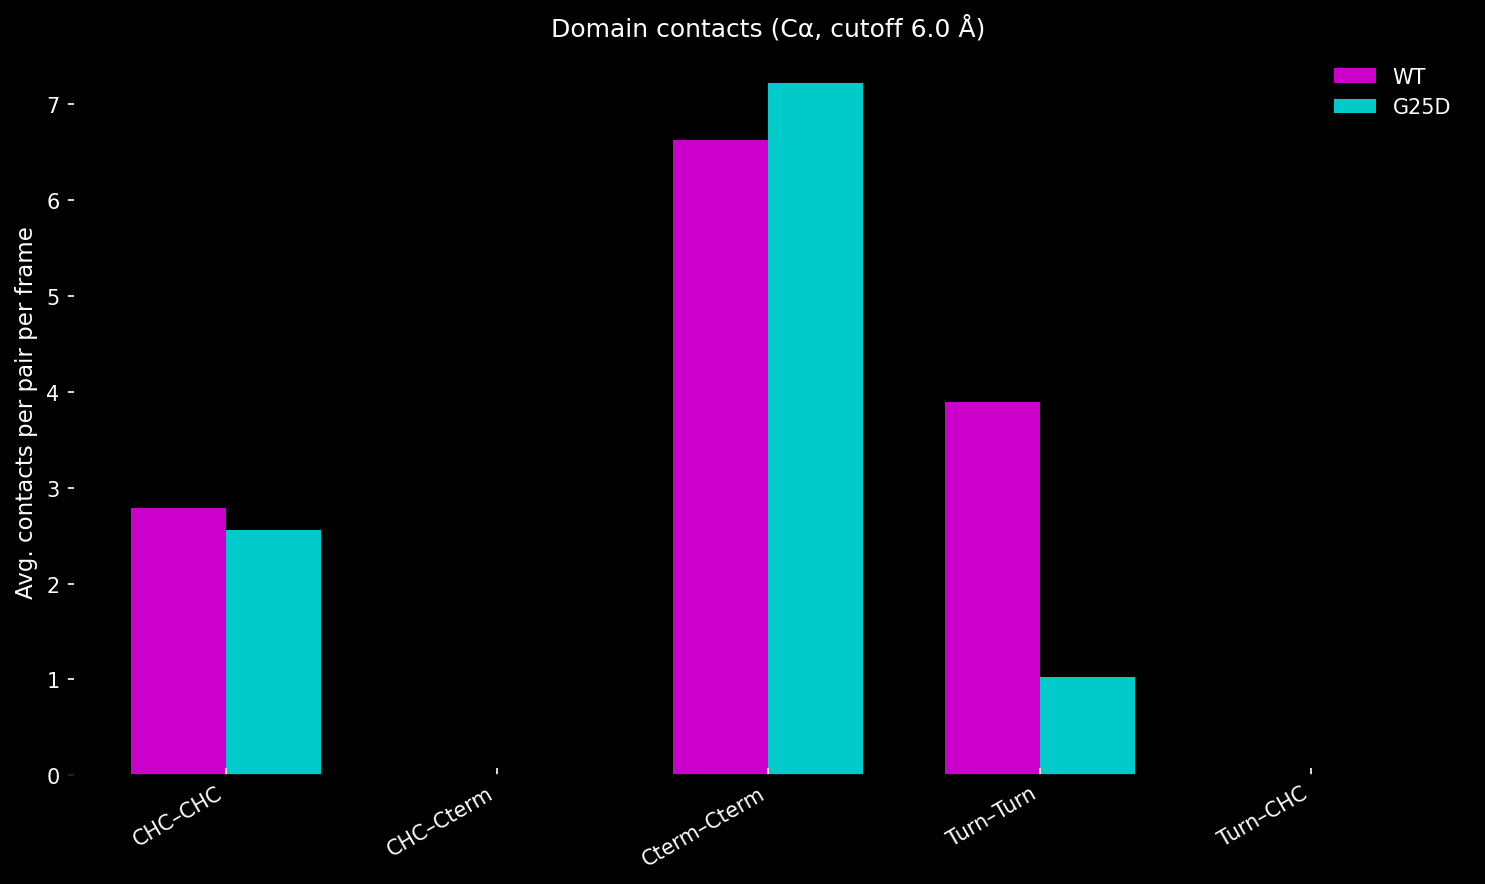

<Figure size 960x720 with 0 Axes>

In [18]:
# Bar plot
labels = list(avg_wt.keys())
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, [avg_wt[k] for k in labels], width, label='WT', color=COLORS["WT"], alpha=0.8)
ax.bar(x + width/2, [avg_mut[k] for k in labels], width, label='G25D', color=COLORS["G25D"], alpha=0.8)
ax.set_ylabel('Avg. contacts per pair per frame')
ax.set_title(f'Domain contacts (Cα, cutoff {DOMAIN_CONTACT_CUTOFF} Å)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig('../../images/tetramers_domain_contacts_comparison.png', dpi=300, bbox_inches='tight')

### The introduction of the mutation resulted in a noticeable reduction in contact between the two Turn regions.  3.894 for WT vs 1.027 for G25D